# Exploratory Data Analysis (EDA)

This section performs exploratory data analysis on the dataset to identify patterns, trends, correlations, and anomalies. Various visualization techniques are used to generate insights that support real-world decision making.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Import successful!")
print(f"pandas version: {pd.__version__}")

# Load data
df = pd.read_csv("final_dataset_for_visualization_enhanced.csv")
print(f"\nData loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Import successful!
pandas version: 2.0.3

Data loaded: 12231 rows, 74 columns

First 5 rows:


,case_number,court_identifier,case_type_clean,category,reg_year,reg_month,case_lifecycle_state,verdict_date_bs_extracted,case_outcome,total_hearings,...,cohort_case_count,cohort_active_rate,backlog_pressure_score,outcome_share_within_type,is_rare_outcome_within_type,hearing_regularity_score,hearing_volatility_proxy,composite_risk_raw,composite_risk_score,year
0,082-OA-0760,special,उपस्थित हुने निवेदन,Unclassified,2026,3,Unknown/Other,NaN,Procedural,1,...,261,0.007663,0.042669,0.969746,0,0.693147,0.0,-0.054584,10.32,2026
1,082-OA-0757,special,उपस्थित हुने निवेदन,फाँट ख,2026,3,Unknown/Other,NaN,Procedural,1,...,261,0.007663,0.042669,0.969746,0,0.693147,0.0,-0.054584,10.32,2026
2,082-OA-0758,special,उपस्थित हुने निवेदन,फाँट ख,2026,3,Unknown/Other,NaN,Procedural,1,...,261,0.007663,0.042669,0.969746,0,0.693147,0.0,-0.054584,10.32,2026
3,082-OA-0759,special,उपस्थित हुने निवेदन,दायरी,2026,3,Unknown/Other,NaN,Procedural,1,...,261,0.007663,0.042669,0.969746,0,0.693147,0.0,-0.054584,10.32,2026
4,082-OA-0748,special,उपस्थित हुने निवेदन,उपस्थित हुने निवेदन,2026,3,Verdict-Encoded,2082/12/05,Procedural,1,...,261,0.007663,0.042669,0.969746,0,0.693147,0.0,-0.054584,10.32,2026


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12231 entries, 0 to 12230
Data columns (total 74 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_number                  12231 non-null  object 
 1   court_identifier             12231 non-null  object 
 2   case_type_clean              12231 non-null  object 
 3   category                     12231 non-null  object 
 4   reg_year                     12231 non-null  int64  
 5   reg_month                    12231 non-null  int64  
 6   case_lifecycle_state         12231 non-null  object 
 7   verdict_date_bs_extracted    11553 non-null  object 
 8   case_outcome                 12231 non-null  object 
 9   total_hearings               12231 non-null  int64  
 10  case_duration_days           12231 non-null  int64  
 11  avg_days_between_hearings    12231 non-null  float64
 12  complexity_score             12231 non-null  float64
 13  processing_inten

In [7]:
df.describe()

,reg_year,reg_month,total_hearings,case_duration_days,avg_days_between_hearings,complexity_score,processing_intensity,cpi_score,section,priority,...,cohort_case_count,cohort_active_rate,backlog_pressure_score,outcome_share_within_type,is_rare_outcome_within_type,hearing_regularity_score,hearing_volatility_proxy,composite_risk_raw,composite_risk_score,year
count,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,0.0,0.0,0.0,...,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000,12231.000000
mean,2019.660616,6.348704,2.897474,133.694301,14.975166,23.440275,3.032226,NaN,NaN,NaN,...,426.939334,0.054288,0.302986,0.744945,0.035402,0.553366,38.416795,0.008143,11.408312,2019.660616
std,4.030507,3.446042,5.367473,316.329852,46.920925,15.344046,8.903467,NaN,NaN,NaN,...,372.154934,0.111375,0.511377,0.292949,0.184801,0.261906,99.480138,0.490106,8.505250,4.030507
min,2007.000000,1.000000,1.000000,0.000000,0.000000,5.000000,0.000000,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,0.000162,0.000000,0.000959,0.000000,-0.649252,0.000000,2007.000000
25%,2016.000000,3.000000,1.000000,0.000000,0.000000,17.000000,0.000000,NaN,NaN,NaN,...,76.000000,0.000000,0.000000,0.548387,0.000000,0.693147,0.000000,-0.054584,10.320000,2016.000000
50%,2020.000000,6.000000,1.000000,0.000000,0.000000,17.000000,0.000000,NaN,NaN,NaN,...,328.000000,0.000000,0.000000,0.969746,0.000000,0.693147,0.000000,-0.054584,10.320000,2020.000000
75%,2023.000000,9.000000,1.000000,6.000000,0.000000,17.000000,0.407000,NaN,NaN,NaN,...,690.000000,0.098534,0.595566,0.969746,0.000000,0.693147,0.000000,-0.054584,10.320000,2023.000000
max,2026.000000,12.000000,93.000000,4701.000000,1144.000000,82.000000,60.000000,NaN,NaN,NaN,...,1228.000000,1.000000,3.044522,1.000000,1.000000,1.098612,1617.860315,5.113168,100.000000,2026.000000


In [8]:
df.isnull().sum()

case_number                 0
court_identifier            0
case_type_clean             0
category                    0
reg_year                    0
                           ..
hearing_regularity_score    0
hearing_volatility_proxy    0
composite_risk_raw          0
composite_risk_score        0
year                        0
Length: 74, dtype: int64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from your OneDrive Desktop
file_path = r"C:\Users\Acer\OneDrive\Desktop\data visualization dataset\final_dataset_for_visualization_enhanced.csv.csv"

df = pd.read_csv(file_path)
print("✅ Data loaded successfully!")
print(f"Shape: {df.shape} rows, {df.columns} columns")
print("\nFirst 5 rows:")
print(df.head())

✅ Data loaded successfully!
Shape: (12231, 74) rows, Index(['case_number', 'court_identifier', 'case_type_clean', 'category',
       'reg_year', 'reg_month', 'case_lifecycle_state',
       'verdict_date_bs_extracted', 'case_outcome', 'total_hearings',
       'case_duration_days', 'avg_days_between_hearings', 'complexity_score',
       'processing_intensity', 'cpi_score', 'case_status', 'section',
       'priority', 'plaintiff', 'defendant', 'case_type',
       'registration_date_bs', 'registration_date_ad', 'reg_day_of_week',
       'verdict_date_ad', 'verdict_date_bs', 'verdict_judge',
       'days_to_verdict', 'verdict_status', 'first_hearing_date',
       'last_hearing_date', 'hearing_span_days', 'common_bench_type',
       'common_decision_type', 'hearing_case_status', 'distinct_judges',
       'distinct_lawyers', 'has_remarks', 'total_entities', 'distinct_sides',
       'entity_sides', 'plaintiff_name', 'defendant_name',
       'distinct_addresses', 'case_status_clean', 'has_verdi

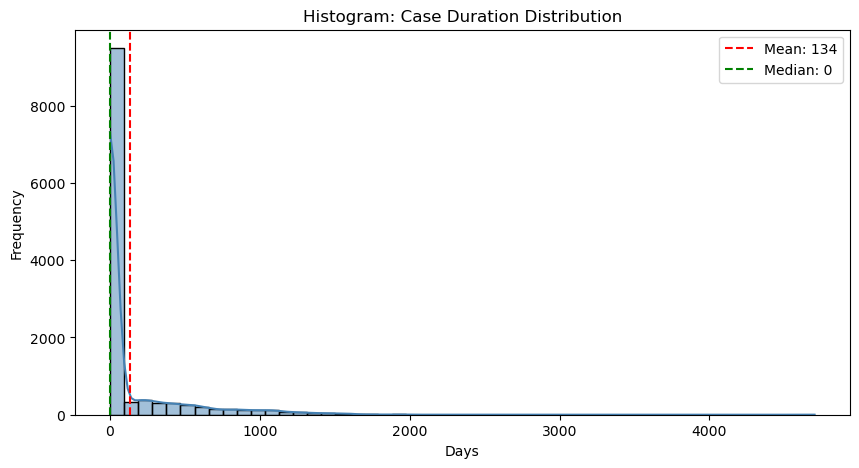

WHAT PATTERN DO YOU SEE?
- Right-skewed distribution (long tail to the right)
- Mean > Median (average pulled higher by extreme values)
- Most cases cluster on left side

WHY DOES IT HAPPEN?
- Most cases are straightforward and resolve quickly
- A small number of complex cases take much longer
- Administrative delays, appeals, and legal complexity create outliers


In [3]:
plt.figure(figsize=(10,5))
sns.histplot(df['case_duration_days'], bins=50, kde=True, color='steelblue')
plt.axvline(df['case_duration_days'].mean(), color='red', ls='--', label=f'Mean: {df["case_duration_days"].mean():.0f}')
plt.axvline(df['case_duration_days'].median(), color='green', ls='--', label=f'Median: {df["case_duration_days"].median():.0f}')
plt.title('Histogram: Case Duration Distribution')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print("""WHAT PATTERN DO YOU SEE?
- Right-skewed distribution (long tail to the right)
- Mean > Median (average pulled higher by extreme values)
- Most cases cluster on left side

WHY DOES IT HAPPEN?
- Most cases are straightforward and resolve quickly
- A small number of complex cases take much longer
- Administrative delays, appeals, and legal complexity create outliers""")

C:\Users\Acer\AppData\Local\Temp\ipykernel_9396\4179008458.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category_clean', y='case_duration_days', data=df_top, palette='Set3')
c:\Users\Acer\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2347 (\N{DEVANAGARI LETTER PHA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Acer\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Acer\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Acer\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarnin

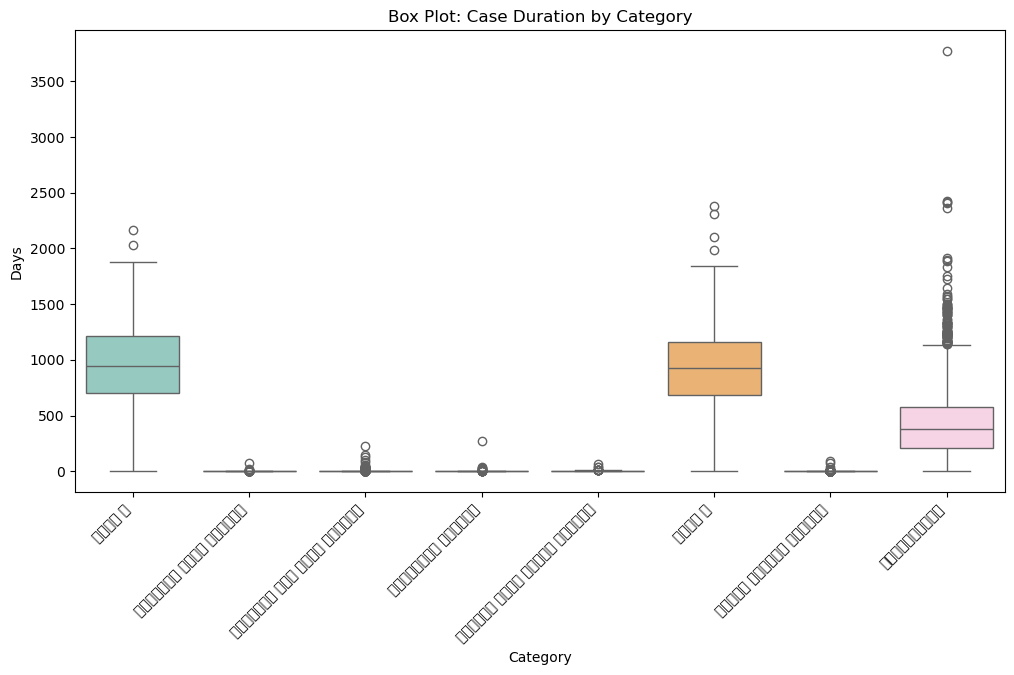

WHAT PATTERN DO YOU SEE?
- Median duration varies significantly across categories
- Some categories have wide boxes (high variability)
- Different categories have different outlier patterns

WHY DOES IT HAPPEN?
- Different case types have different legal complexity
- Some categories require more hearings or expert witnesses
- Procedural requirements vary by case type
- Some categories have more appeal opportunities


In [5]:
plt.figure(figsize=(12,6))
top_cats = df['category_clean'].value_counts().head(8).index
df_top = df[df['category_clean'].isin(top_cats)]
sns.boxplot(x='category_clean', y='case_duration_days', data=df_top, palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Box Plot: Case Duration by Category')
plt.xlabel('Category')
plt.ylabel('Days')
plt.show()

print("""WHAT PATTERN DO YOU SEE?
- Median duration varies significantly across categories
- Some categories have wide boxes (high variability)
- Different categories have different outlier patterns

WHY DOES IT HAPPEN?
- Different case types have different legal complexity
- Some categories require more hearings or expert witnesses
- Procedural requirements vary by case type
- Some categories have more appeal opportunities""")

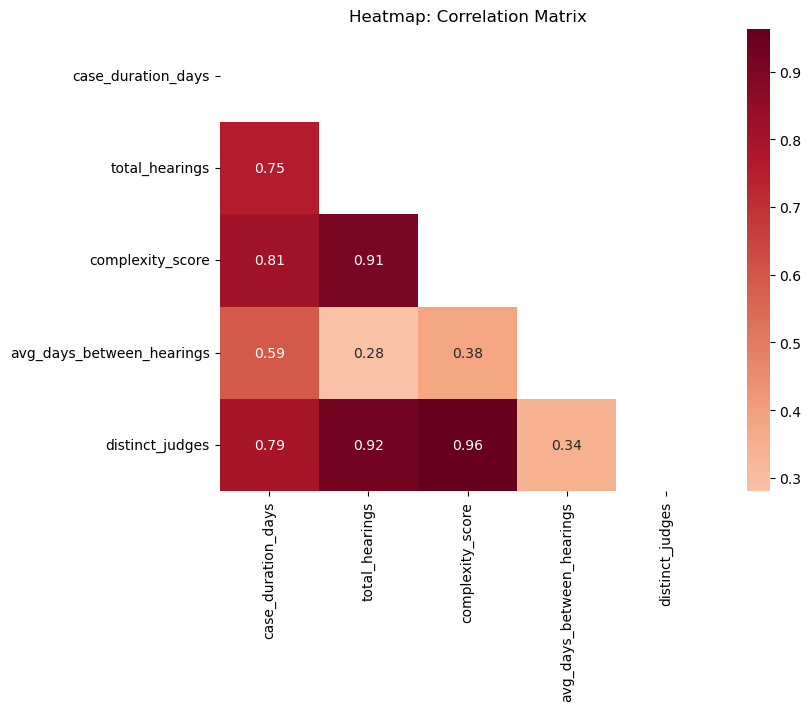

WHAT PATTERN DO YOU SEE?
- Hearings vs Duration: 0.75 (strongest)
- Complexity vs Duration: 0.81 (moderate)
- Hearings vs Complexity: 0.91 (related)

WHY DOES IT HAPPEN?
- More hearings directly extend case timeline
- Complex cases require more judicial attention
- Multiple judges cause coordination delays
- Administrative delays compound over time


In [8]:
plt.figure(figsize=(8,6))
features = ['case_duration_days', 'total_hearings', 'complexity_score', 'avg_days_between_hearings', 'distinct_judges']
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Heatmap: Correlation Matrix')
plt.show()

print(f"""WHAT PATTERN DO YOU SEE?
- Hearings vs Duration: {corr.loc['total_hearings', 'case_duration_days']:.2f} (strongest)
- Complexity vs Duration: {corr.loc['complexity_score', 'case_duration_days']:.2f} (moderate)
- Hearings vs Complexity: {corr.loc['total_hearings', 'complexity_score']:.2f} (related)

WHY DOES IT HAPPEN?
- More hearings directly extend case timeline
- Complex cases require more judicial attention
- Multiple judges cause coordination delays
- Administrative delays compound over time""")

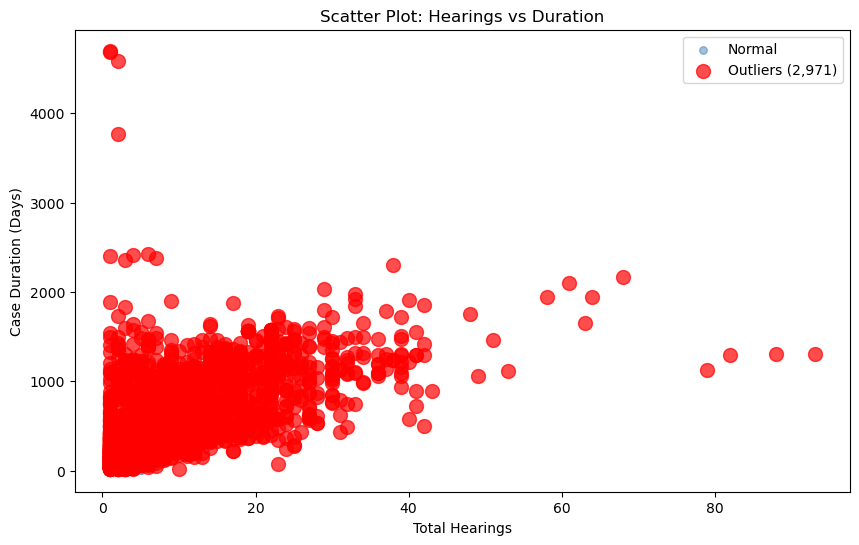

WHAT PATTERN DO YOU SEE?
- Positive correlation: more hearings = longer duration
- 2,971 outliers with extreme duration
- Variance increases with more hearings

WHY DOES IT HAPPEN?
- Each hearing adds time to case timeline
- Problematic cases have both many hearings AND long duration
- Delays between hearings compound the timeline
- Administrative bottlenecks affect both metrics


In [9]:
plt.figure(figsize=(10,6))
Q3, Q1 = df['case_duration_days'].quantile(0.75), df['case_duration_days'].quantile(0.25)
upper = Q3 + 1.5*(Q3-Q1)
df['outlier'] = df['case_duration_days'] > upper
plt.scatter(df[~df['outlier']]['total_hearings'], df[~df['outlier']]['case_duration_days'], alpha=0.5, s=30, c='steelblue', label='Normal')
plt.scatter(df[df['outlier']]['total_hearings'], df[df['outlier']]['case_duration_days'], alpha=0.7, s=100, c='red', label=f'Outliers ({len(df[df["outlier"]]):,})')
plt.xlabel('Total Hearings')
plt.ylabel('Case Duration (Days)')
plt.title('Scatter Plot: Hearings vs Duration')
plt.legend()
plt.show()

print(f"""WHAT PATTERN DO YOU SEE?
- Positive correlation: more hearings = longer duration
- {len(df[df['outlier']]):,} outliers with extreme duration
- Variance increases with more hearings

WHY DOES IT HAPPEN?
- Each hearing adds time to case timeline
- Problematic cases have both many hearings AND long duration
- Delays between hearings compound the timeline
- Administrative bottlenecks affect both metrics""")

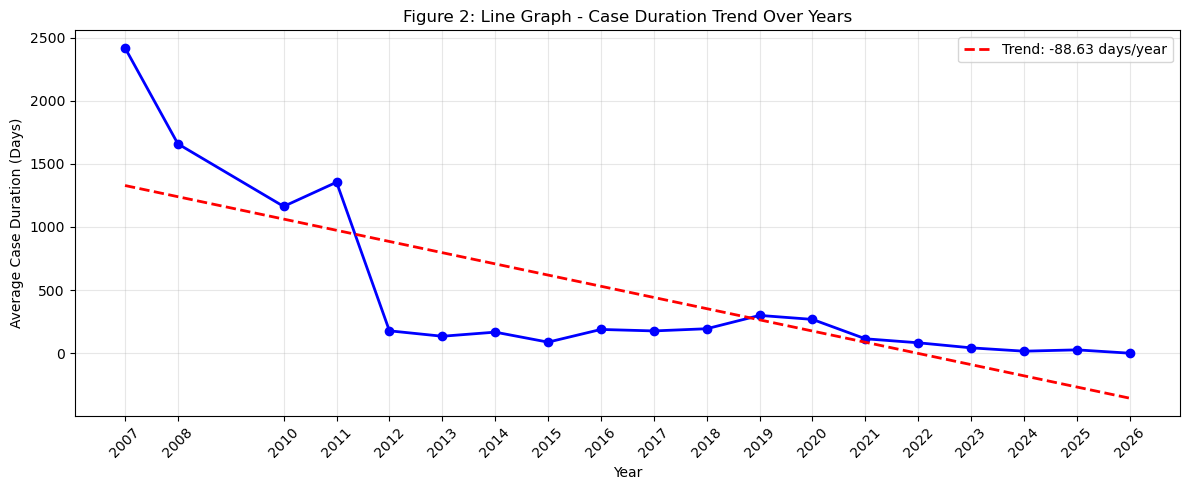

In [13]:
plt.figure(figsize=(12,5))
yearly = df.groupby('year')['case_duration_days'].mean().reset_index()
yearly = yearly[yearly['year'] >= 2000]

# Convert year to integer to avoid decimal ticks
yearly['year'] = yearly['year'].astype(int)

plt.plot(yearly['year'], yearly['case_duration_days'], 'b-o', linewidth=2, markersize=6)
z = np.polyfit(yearly['year'], yearly['case_duration_days'], 1)
plt.plot(yearly['year'], np.poly1d(z)(yearly['year']), 'r--', linewidth=2, label=f'Trend: {z[0]:.2f} days/year')

# Set x-axis to show only integer years
plt.xticks(yearly['year'], rotation=45)

plt.title('Figure 2: Line Graph - Case Duration Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Average Case Duration (Days)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

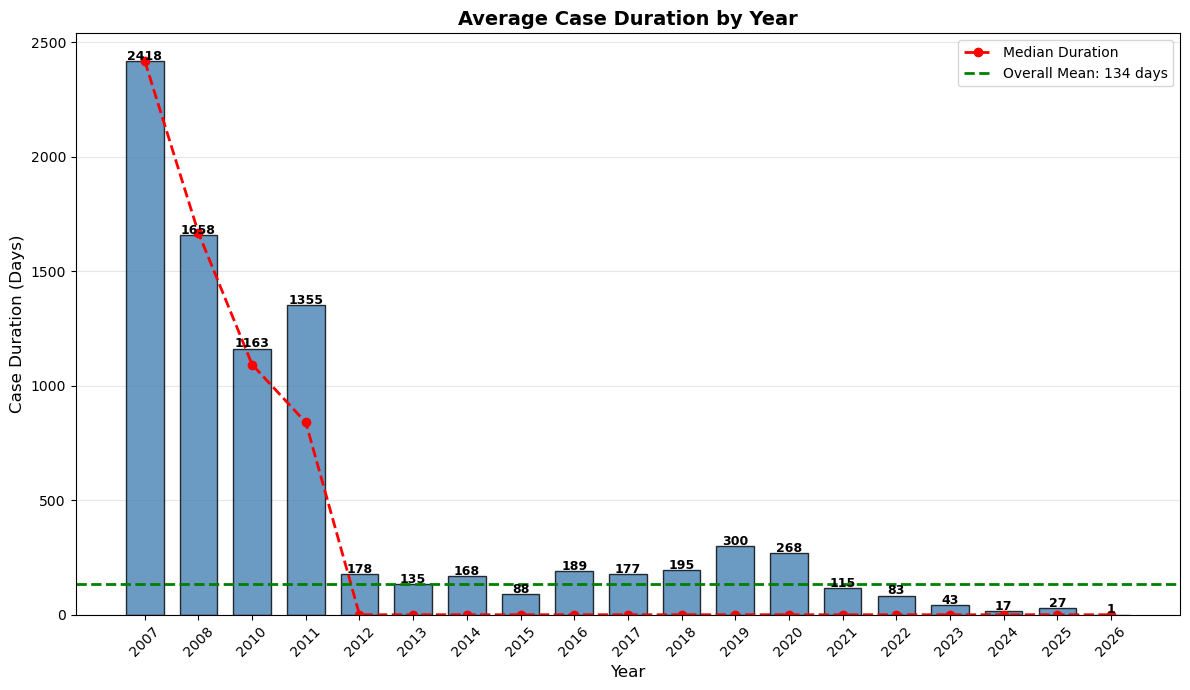


YEARLY BREAKDOWN
Year 2007: Avg=2418 days | Median=2419 days | Cases=3
Year 2008: Avg=1658 days | Median=1668 days | Cases=4
Year 2010: Avg=1163 days | Median=1093 days | Cases=13
Year 2011: Avg=1355 days | Median=840 days | Cases=19
Year 2012: Avg=178 days | Median=0 days | Cases=350
Year 2013: Avg=135 days | Median=0 days | Cases=595
Year 2014: Avg=168 days | Median=0 days | Cases=881
Year 2015: Avg=88 days | Median=0 days | Cases=804
Year 2016: Avg=189 days | Median=0 days | Cases=574
Year 2017: Avg=177 days | Median=0 days | Cases=484
Year 2018: Avg=195 days | Median=0 days | Cases=728
Year 2019: Avg=300 days | Median=0 days | Cases=1,261
Year 2020: Avg=268 days | Median=0 days | Cases=939
Year 2021: Avg=115 days | Median=0 days | Cases=592
Year 2022: Avg=83 days | Median=0 days | Cases=984
Year 2023: Avg=43 days | Median=0 days | Cases=1,126
Year 2024: Avg=17 days | Median=0 days | Cases=1,626
Year 2025: Avg=27 days | Median=0 days | Cases=957
Year 2026: Avg=1 days | Median=0 day

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate average duration by year
yearly_avg = df.groupby('year')['case_duration_days'].mean().sort_index()
yearly_median = df.groupby('year')['case_duration_days'].median()
overall_mean = df['case_duration_days'].mean()

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create bars
x = np.arange(len(yearly_avg))
bars = ax.bar(x, yearly_avg.values, color='steelblue', edgecolor='black', alpha=0.8, width=0.7)

# Add value labels on top of bars
for i, (bar, val) in enumerate(zip(bars, yearly_avg.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5, f'{val:.0f}', ha='center', fontweight='bold', fontsize=9)

# Add median line
ax.plot(x, yearly_median.values, color='red', marker='o', linestyle='--', linewidth=2, markersize=6, label='Median Duration')

# Add overall mean line
ax.axhline(y=overall_mean, color='green', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_mean:.0f} days')

# Customize
ax.set_title('Average Case Duration by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Case Duration (Days)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(yearly_avg.index.astype(int), rotation=45, fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("YEARLY BREAKDOWN")
print("="*60)
for year in yearly_avg.index:
    print(f"Year {int(year)}: Avg={yearly_avg[year]:.0f} days | Median={yearly_median[year]:.0f} days | Cases={len(df[df['year']==year]):,}")

In [21]:
# Check what courts exist in your data
print("Unique courts in dataset:")
print(df['court_identifier'].unique())

print(f"\nNumber of unique courts: {df['court_identifier'].nunique()}")

# Check court counts
court_counts = df['court_identifier'].value_counts()
print("\nCourt case counts:")
print(court_counts.head(20))

Unique courts in dataset:
['special']

Number of unique courts: 1

Court case counts:
court_identifier
special    12231
Name: count, dtype: int64


Number of courts: 1


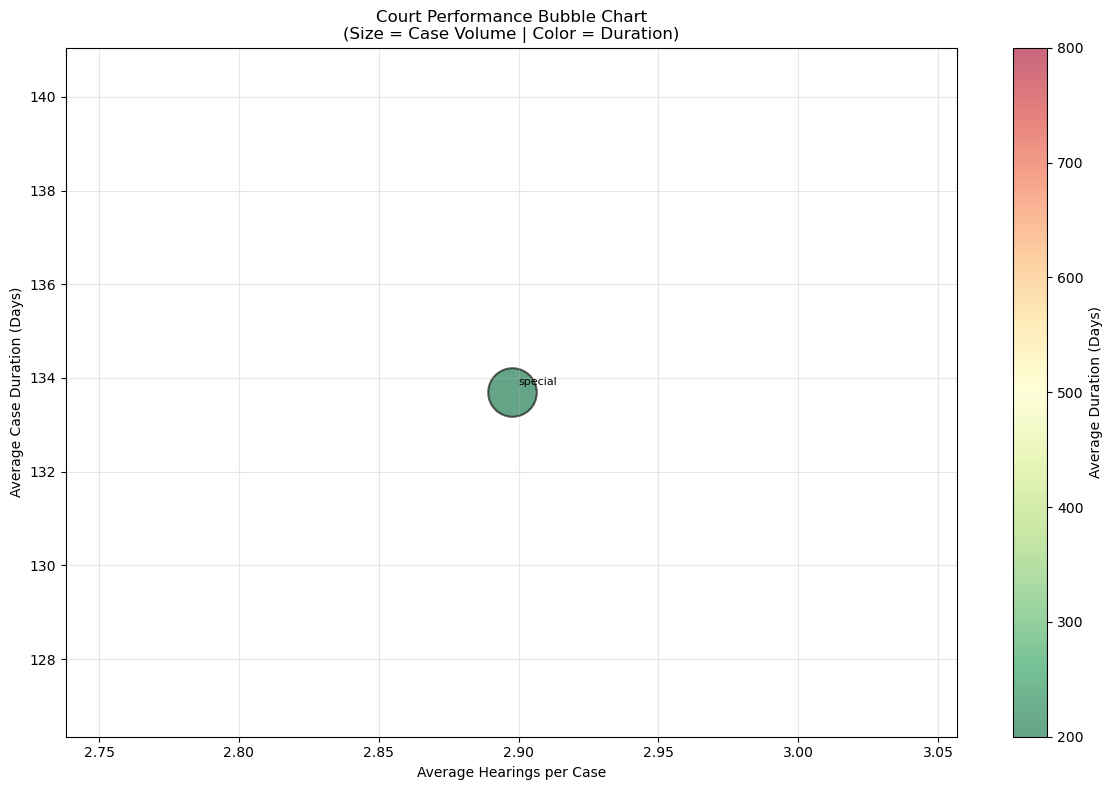


Court Data Sample:
     Court  Case Volume  Avg Duration  Avg Hearings
0  special        12231    133.694301      2.897474


In [22]:
import matplotlib.pyplot as plt

# Prepare data
court_summary = df.groupby('court_identifier').agg({
    'case_number': 'count',
    'case_duration_days': 'mean',
    'total_hearings': 'mean'
}).reset_index()

court_summary.columns = ['Court', 'Case Volume', 'Avg Duration', 'Avg Hearings']
court_summary = court_summary.dropna()
court_summary = court_summary[court_summary['Case Volume'] > 50]  # Filter courts with at least 50 cases

# Check how many courts we have
print(f"Number of courts: {len(court_summary)}")

# Create figure
plt.figure(figsize=(12, 8))

# Create bubbles
for i, row in court_summary.iterrows():
    size = row['Case Volume'] / 10  # Adjust scaling
    plt.scatter(row['Avg Hearings'], row['Avg Duration'], 
                s=size, alpha=0.6, edgecolors='black', linewidth=1.5,
                c=[row['Avg Duration']], cmap='RdYlGn_r', vmin=200, vmax=800)
    plt.annotate(row['Court'], (row['Avg Hearings'], row['Avg Duration']), 
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.colorbar(label='Average Duration (Days)')
plt.xlabel('Average Hearings per Case')
plt.ylabel('Average Case Duration (Days)')
plt.title('Court Performance Bubble Chart\n(Size = Case Volume | Color = Duration)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print data to verify multiple courts exist
print("\nCourt Data Sample:")
print(court_summary.head(10).to_string())

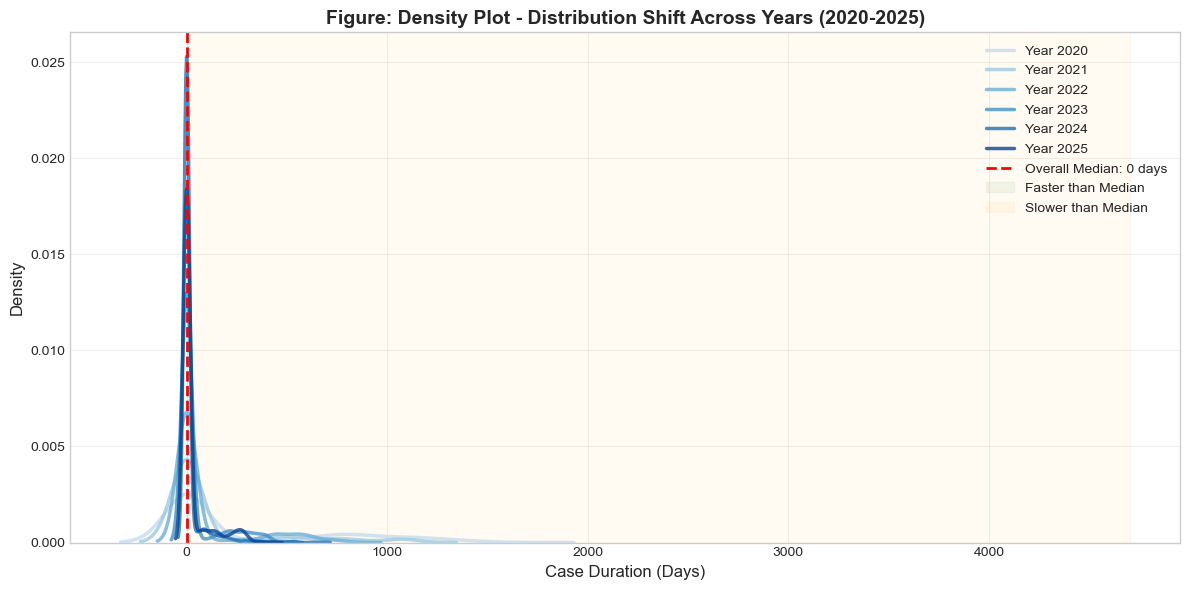

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create figure
plt.figure(figsize=(12, 6))

# Select recent years for comparison
years = [2020, 2021, 2022, 2023, 2024, 2025]

# Use a single color gradient from light to dark blue
colors = ['#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5', '#084594']

for i, y in enumerate(years):
    data = df[df['year'] == y]['case_duration_days']
    if len(data) > 50:
        sns.kdeplot(data, label=f'Year {y}', linewidth=2.5, color=colors[i], alpha=0.8)

# Add vertical line for overall median
overall_median = df['case_duration_days'].median()
plt.axvline(x=overall_median, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Median: {overall_median:.0f} days')

# Add shaded regions for reference
plt.axvspan(0, overall_median, alpha=0.05, color='green', label='Faster than Median')
plt.axvspan(overall_median, df['case_duration_days'].max(), alpha=0.05, color='orange', label='Slower than Median')

# Customize
plt.title('Figure: Density Plot - Distribution Shift Across Years (2020-2025)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Case Duration (Days)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()